# KNN - Implementation

- Problem statement: Given the age and and estimated salary predict whether the user will buy the product or not
- Target variable = Purchased - boolean
- As KNN is a distance based model, feature scaling is important

In [1]:
import pandas as pd

df = pd.read_csv("../../../../datasets/Social_Network_Ads.csv")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


# Seperating independent and independent variables

In [2]:
X = df.drop(columns = ["Purchased"])
y = df["Purchased"]

# Splitting the dataset into train and test

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"Length of training set: {len(X_train)}")
print(f"Length of test set: {len(X_test)}")

Length of training set: 320
Length of test set: 80


# Feature Scaling
- Only 1 scaler is defined which is for the independent variables
- There is no scaler defined for dependent/ target variable as its a boolean flag

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Training the model

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Default values are used, if metric is minkowski and power is 2 then its Euclidean Distance
model = KNeighborsClassifier(n_neighbors=5, metric = "minkowski", p = 2)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [6]:
for i, j in zip(y_test, y_pred):
    print(f"True: {i} Predicted: {j}")

True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 1 Predicted: 1
True: 1 Predicted: 1
True: 1 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 1 Predicted: 0
True: 1 Predicted: 1
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 0
True: 0 Predicted: 0
True: 1 Predicted: 1
True: 0 Predicted: 1
True: 1 Predicted: 0
True: 1 Predicted: 1
True: 1 Predicted: 1
True: 0 Predi

# Creating Confusion Matrix

<Axes: >

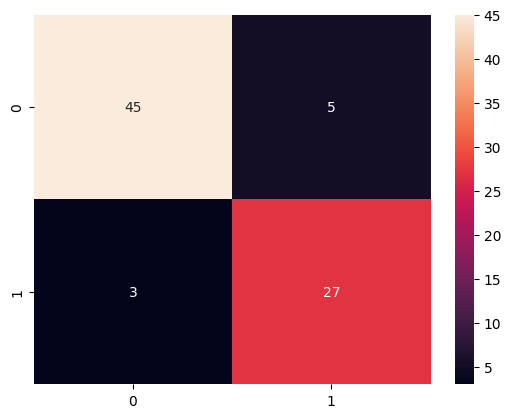

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

con_matrix = confusion_matrix(y_true = y_test, y_pred = y_pred)

sns.heatmap(con_matrix, annot = True)

# Computing the accuracy of the model

In [8]:
from sklearn.metrics import accuracy_score

print("Train Accuracy Score",accuracy_score(y_true = y_train, y_pred = model.predict(X_train_scaled)))
print("Test Accuracy Score",accuracy_score(y_true = y_test, y_pred = y_pred))


Train Accuracy Score 0.915625
Test Accuracy Score 0.9
